# Comparaison des modèles de consommation électrique

Ce notebook explique les étapes suivies afin de sélectionner l'algorithme de machine learning le plus adapté à notre besoin dans le cadre du projet EnerVision

Synthèse pour short list d'algo :

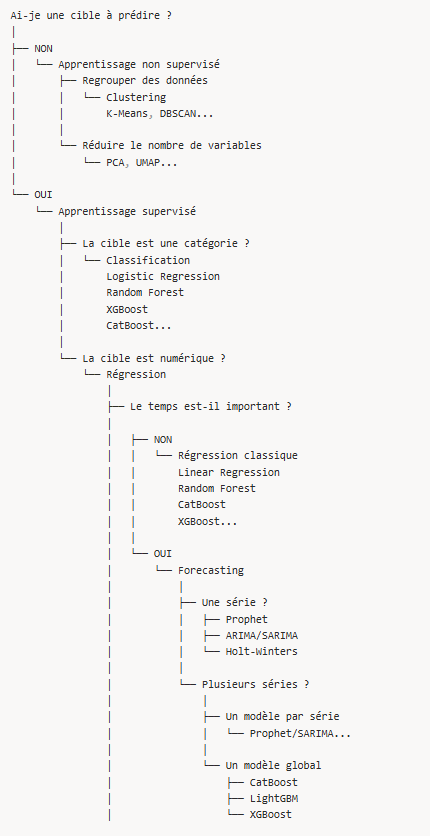

Deux critères principaux ont été retenus pour guider la sélection du modèle :

- le modèle doit être capable de produire des prévisions sur un horizon compris entre **1 heure et 7 jours maximum** ;
- le modèle doit obtenir une **MAE relative inférieure à 20 % sur l'ensemble des sites** afin d'être considéré comme acceptable pour le MVP.


Après cette première analyse, deux approches ressortaient particulièrement.

**Prophet** est un algorithme spécialisé dans le **forecasting de séries temporelles**. Il apprend directement à partir de l’historique les tendances et les saisonnalités, par exemple journalières, hebdomadaires ou annuelles. Il est particulièrement adapté lorsqu’on travaille sur une série temporelle donnée, mais il est moins naturel dans notre cas où l’on souhaite disposer d’un modèle global capable de gérer plusieurs sites très différents.

**CatBoost** est un algorithme de **Gradient Boosting** basé sur des arbres de décision. Contrairement à Prophet, il ne comprend pas directement la dimension temporelle : celle-ci doit être transformée en features comme l’heure, le jour de la semaine, les lags ou les moyennes glissantes. En revanche, il permet d’entraîner un modèle global sur l’ensemble des sites.

Parmi les principales implémentations de Gradient Boosting — CatBoost, LightGBM et XGBoost — CatBoost était particulièrement intéressant pour notre cas car il permet de gérer nativement les variables catégorielles comme site_id et site_type.

## 1. Importer les bibliothèques

On importe les outils utilisés pour préparer les données, entraîner les modèles et calculer les erreurs.

In [1]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2. Charger et découvrir les données

On charge le fichier puis on vérifie sa taille, ses colonnes et ses valeurs manquantes.

In [2]:
raw_data = pd.read_csv("../datas/all_sites_combined.csv")
raw_data.head()

,timestamp,site_id,site_type,site_name,consumption_kwh,consumption_euros,temperature_celsius,humidity_percent,solar_irradiance_wm2,hour,day_of_week,day_name,month,is_weekend,is_working_hours
0,2023-01-01 00:00:00,SITE001,office,Bureau Tertiaire,85.82,12.87,10.6,76.7,0.0,0,6,Sunday,1,1,0
1,2023-01-01 01:00:00,SITE001,office,Bureau Tertiaire,89.84,13.48,12.0,70.6,0.0,1,6,Sunday,1,1,0
2,2023-01-01 02:00:00,SITE001,office,Bureau Tertiaire,80.62,12.09,13.8,62.2,0.0,2,6,Sunday,1,1,0
3,2023-01-01 03:00:00,SITE001,office,Bureau Tertiaire,92.67,13.90,9.4,66.0,0.0,3,6,Sunday,1,1,0
4,2023-01-01 04:00:00,SITE001,office,Bureau Tertiaire,72.50,10.88,14.8,67.2,41.5,4,6,Sunday,1,1,0


In [3]:
print("Dimensions :", raw_data.shape)
print("______________________________________________")
raw_data.info()

Dimensions : (122647, 15)
______________________________________________
<class 'pandas.DataFrame'>
RangeIndex: 122647 entries, 0 to 122646
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   timestamp             122647 non-null  str    
 1   site_id               122647 non-null  str    
 2   site_type             122647 non-null  str    
 3   site_name             122647 non-null  str    
 4   consumption_kwh       119807 non-null  float64
 5   consumption_euros     120160 non-null  float64
 6   temperature_celsius   119231 non-null  float64
 7   humidity_percent      119224 non-null  float64
 8   solar_irradiance_wm2  118683 non-null  float64
 9   hour                  122647 non-null  int64  
 10  day_of_week           122647 non-null  int64  
 11  day_name              122647 non-null  str    
 12  month                 122647 non-null  int64  
 13  is_weekend            122647 non-null  int

In [4]:
# Compter les valeurs manquantes dans chaque colonne.
raw_data.isna().sum()

timestamp                  0
site_id                    0
site_type                  0
site_name                  0
consumption_kwh         2840
consumption_euros       2487
temperature_celsius     3416
humidity_percent        3423
solar_irradiance_wm2    3964
hour                       0
day_of_week                0
day_name                   0
month                      0
is_weekend                 0
is_working_hours           0
dtype: int64

In [5]:
# Convertir le texte en date pour pouvoir trier et découper les données dans le temps.
raw_data["timestamp"] = pd.to_datetime(raw_data["timestamp"])
raw_data["timestamp"].min(), raw_data["timestamp"].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2024-12-31 00:00:00'))

In [6]:
# Résumer la période disponible pour chaque site.
sites_summary = (
    raw_data.groupby(["site_id", "site_name", "site_type"])
    .agg(
        date_debut=("timestamp", "min"),
        date_fin=("timestamp", "max"),
        nombre_lignes=("timestamp", "size"),
    )
    .reset_index()
)
sites_summary

,site_id,site_name,site_type,date_debut,date_fin,nombre_lignes
0,SITE001,Bureau Tertiaire,office,2023-01-01,2024-12-31,17521
1,SITE002,Usine de Production,factory,2023-01-01,2024-12-31,17521
2,SITE003,Data Center,datacenter,2023-01-01,2024-12-31,17521
3,SITE004,Centre Commercial,retail,2023-01-01,2024-12-31,17521
4,SITE005,Hôpital,hospital,2023-01-01,2024-12-31,17521
5,SITE006,Bureau Tertiaire,office,2023-01-01,2024-12-31,17521
6,SITE007,Usine de Production,factory,2023-01-01,2024-12-31,17521


## 3. Préparer les données

On garde les colonnes utiles, on trie les lignes et on contrôle les doublons.

In [7]:
selected_columns = [
    "site_id",
    "timestamp",
    "site_type",
    "consumption_kwh",
    "temperature_celsius",
    "humidity_percent",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_working_hours",
]

clean_data = (
    raw_data[selected_columns]
    .sort_values(["site_id", "timestamp"])
    .reset_index(drop=True)
    .copy()
)
clean_data.head()

,site_id,timestamp,site_type,consumption_kwh,temperature_celsius,humidity_percent,hour,day_of_week,month,is_weekend,is_working_hours
0,SITE001,2023-01-01 00:00:00,office,85.82,10.6,76.7,0,6,1,1,0
1,SITE001,2023-01-01 01:00:00,office,89.84,12.0,70.6,1,6,1,1,0
2,SITE001,2023-01-01 02:00:00,office,80.62,13.8,62.2,2,6,1,1,0
3,SITE001,2023-01-01 03:00:00,office,92.67,9.4,66.0,3,6,1,1,0
4,SITE001,2023-01-01 04:00:00,office,72.50,14.8,67.2,4,6,1,1,0


In [8]:
# Un site ne doit pas avoir deux lignes pour la même heure.
clean_data.duplicated(subset=["site_id", "timestamp"]).sum()

np.int64(0)

In [9]:
# Vérifier les valeurs manquantes séparément pour chaque site.
missing_by_site = (
    raw_data.groupby("site_id")[
        [
            "consumption_kwh",
            "temperature_celsius",
            "humidity_percent",
            "solar_irradiance_wm2",
        ]
    ]
    .apply(lambda values: values.isna().sum())
)
missing_by_site

,consumption_kwh,temperature_celsius,humidity_percent,solar_irradiance_wm2
site_id,,,,
SITE001,411,491,494,566
SITE002,407,491,489,569
SITE003,407,488,491,571
SITE004,405,485,487,576
SITE005,409,493,493,559
SITE006,398,491,489,558
SITE007,403,477,480,565


### Remplacer les valeurs manquantes

On crée des colonnes corrigées pour conserver les colonnes d'origine. Pour chaque site, `ffill()` reprend la dernière valeur connue.

In [10]:
clean_data["consumption_kwh_corrected"] = (
    clean_data.groupby("site_id")["consumption_kwh"].ffill()
)
clean_data["temperature_celsius_corrected"] = (
    clean_data.groupby("site_id")["temperature_celsius"].ffill()
)
clean_data["humidity_percent_corrected"] = (
    clean_data.groupby("site_id")["humidity_percent"].ffill()
)

In [11]:
# Vérifier qu'il ne reste plus de valeur manquante dans les colonnes corrigées.
clean_data[
    [
        "consumption_kwh_corrected",
        "temperature_celsius_corrected",
        "humidity_percent_corrected",
    ]
].isna().sum()

consumption_kwh_corrected        0
temperature_celsius_corrected    0
humidity_percent_corrected       0
dtype: int64

## 4. Séparer les données dans le temps

On utilise les 70 % premières dates pour l'entraînement, les 15 % suivantes pour la validation et les 15 % dernières pour le test. Le tri chronologique évite de mélanger le passé et le futur.

*Dans notre dataset de deux ans, 70/15/15 nous donne beaucoup de données pour entraîner tout en gardant environ trois mois pour la validation et trois mois pour le test.
C’est une convention courante pour garder assez de données pour apprendre, tout en conservant deux blocs séparés pour évaluer le modèle (on aurait aussi pu faire 80/10/10, 60/20/20 ou encore 70/20/10...*

In [12]:
clean_data = clean_data.sort_values(["timestamp", "site_id"]).reset_index(drop=True)

train_end = clean_data["timestamp"].quantile(0.70)
validation_end = clean_data["timestamp"].quantile(0.85)

train_data = clean_data[clean_data["timestamp"] <= train_end].copy()
validation_data = clean_data[
    (clean_data["timestamp"] > train_end)
    & (clean_data["timestamp"] <= validation_end)
].copy()
test_data = clean_data[clean_data["timestamp"] > validation_end].copy()

In [13]:
print("Train :", train_data["timestamp"].min(), "→", train_data["timestamp"].max())
print("Validation :", validation_data["timestamp"].min(), "→", validation_data["timestamp"].max())
print("Test :", test_data["timestamp"].min(), "→", test_data["timestamp"].max())

print()
print("Tailles :", len(train_data), len(validation_data), len(test_data))

Train : 2023-01-01 00:00:00 → 2024-05-26 00:00:00
Validation : 2024-05-26 01:00:00 → 2024-09-12 12:00:00
Test : 2024-09-12 13:00:00 → 2024-12-31 00:00:00

Tailles : 85855 18396 18396


In [14]:
# Vérifier les colonnes et les valeurs manquantes dans chaque partie.
train_data.info()
print()
validation_data.info()
print()
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 85855 entries, 0 to 85854
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   site_id                        85855 non-null  str           
 1   timestamp                      85855 non-null  datetime64[us]
 2   site_type                      85855 non-null  str           
 3   consumption_kwh                83886 non-null  float64       
 4   temperature_celsius            83355 non-null  float64       
 5   humidity_percent               83339 non-null  float64       
 6   hour                           85855 non-null  int64         
 7   day_of_week                    85855 non-null  int64         
 8   month                          85855 non-null  int64         
 9   is_weekend                     85855 non-null  int64         
 10  is_working_hours               85855 non-null  int64         
 11  consumption_kwh_corrected 

## 5. Tester Prophet sur SITE001

Prophet attend une colonne `ds` pour la date et une colonne `y` pour la valeur à prédire. On utilise la validation pour mesurer les erreurs du modèle.

*Pour prophet_train, on n’a pas besoin d’utiliser dropna() sur y, car Prophet sait gérer les valeurs manquantes pendant l’entraînement en ignorant les lignes concernées. En revanche, pour la validation et le test, on conserve uniquement les valeurs réelles afin de pouvoir calculer correctement les métriques.*

In [15]:
prophet_train = (
    train_data.loc[
        train_data["site_id"] == "SITE001",
        ["timestamp", "consumption_kwh"],
    ]
    .rename(columns={"timestamp": "ds", "consumption_kwh": "y"})
    .copy()
)

prophet_validation = (
    validation_data.loc[
        validation_data["site_id"] == "SITE001",
        ["timestamp", "consumption_kwh"],
    ]
    .dropna()
    .rename(columns={"timestamp": "ds", "consumption_kwh": "y"})
    .copy()
)

prophet_test = (
    test_data.loc[
        test_data["site_id"] == "SITE001",
        ["timestamp", "consumption_kwh"],
    ]
    .dropna()
    .rename(columns={"timestamp": "ds", "consumption_kwh": "y"})
    .copy()
)

### Prophet avec les réglages par défaut

On entraîne d'abord Prophet sans modifier ses paramètres.

In [16]:
prophet_default_model = Prophet()
prophet_default_model.fit(prophet_train)

prophet_default_forecast = prophet_default_model.predict(
    prophet_validation[["ds"]]
)
prophet_default_forecast.head()

09:52:15 - cmdstanpy - INFO - Chain [1] start processing
09:52:17 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-05-26 07:00:00,126.061561,-3.214961,115.786922,126.061561,126.061561,-70.419615,-70.419615,-70.419615,-34.596747,-34.596747,-34.596747,-35.822868,-35.822868,-35.822868,0.0,0.0,0.0,55.641946
1,2024-05-26 08:00:00,126.071134,19.149568,138.535853,126.071134,126.071134,-50.167806,-50.167806,-50.167806,-14.883007,-14.883007,-14.883007,-35.284799,-35.284799,-35.284799,0.0,0.0,0.0,75.903328
2,2024-05-26 09:00:00,126.080708,49.401586,163.097038,126.080708,126.080708,-19.150273,-19.150273,-19.150273,15.428602,15.428602,15.428602,-34.578875,-34.578875,-34.578875,0.0,0.0,0.0,106.930434
3,2024-05-26 10:00:00,126.090281,79.188863,195.995064,126.090281,126.090281,8.610502,8.610502,8.610502,42.321688,42.321688,42.321688,-33.711186,-33.711186,-33.711186,0.0,0.0,0.0,134.700783
4,2024-05-26 11:00:00,126.099854,85.783549,205.093609,126.099854,126.099854,21.392051,21.392051,21.392051,54.081220,54.081220,54.081220,-32.689169,-32.689169,-32.689169,0.0,0.0,0.0,147.491906


In [17]:
prophet_default_results = prophet_validation[["ds", "y"]].copy()
prophet_default_results["yhat"] = prophet_default_forecast["yhat"].values

prophet_default_mae = mean_absolute_error(
    prophet_default_results["y"], prophet_default_results["yhat"]
)
prophet_default_rmse = np.sqrt(
    mean_squared_error(
        prophet_default_results["y"], prophet_default_results["yhat"]
    )
)

print("MAE Prophet :", prophet_default_mae)
print("RMSE Prophet :", prophet_default_rmse)
prophet_validation["y"].describe()

MAE Prophet : 41.45877873097996
RMSE Prophet : 52.03519183689818


count    2533.000000
mean      106.016704
std        54.163418
min         0.000000
25%        71.730000
50%        82.980000
75%       145.330000
max       591.910000
Name: y, dtype: float64

## 6. Calculer une baseline simple

La baseline prédit la consommation avec la valeur observée 24 heures plus tôt. Elle permet de vérifier si le modèle fait mieux qu'une règle très simple.

In [18]:
site001_data = (
    clean_data[clean_data["site_id"] == "SITE001"]
    .sort_values("timestamp")
    .copy()
)
site001_data["baseline_24h"] = site001_data["consumption_kwh_corrected"].shift(24)

baseline_results = validation_data.loc[
    validation_data["site_id"] == "SITE001",
    ["timestamp", "consumption_kwh"],
].dropna(subset=["consumption_kwh"])

baseline_results = baseline_results.merge(
    site001_data[["timestamp", "baseline_24h"]],
    on="timestamp",
    how="left",
).dropna(subset=["baseline_24h"])

In [19]:
baseline_mae = mean_absolute_error(
    baseline_results["consumption_kwh"], baseline_results["baseline_24h"]
)
baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_results["consumption_kwh"], baseline_results["baseline_24h"]
    )
)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE :", baseline_rmse)

Baseline MAE : 31.08040268456376
Baseline RMSE : 54.66346353712375


*La baseline obtient une MAE meilleure que Prophet avec ses paramètres par défaut, mais un RMSE légèrement moins bon. Le modèle Prophet par défaut n’apporte donc pas encore d’amélioration nette.*

**On va donc maintenant tenter d'améliorer les prédictions de Prophet en venant agir sur les hyperparamètres !**

## 7. Ajouter la saisonnalité annuelle à Prophet

On force Prophet à rechercher un cycle annuel puis on recalcule les mêmes métriques.

*La saisonnalité annuelle n’est pas activée automatiquement par Prophet car le jeu d’entraînement contient moins de deux années complètes. On choisit donc de la forcer afin d’évaluer son apport.*

In [20]:
prophet_yearly_model = Prophet(yearly_seasonality=True)
prophet_yearly_model.fit(prophet_train)

prophet_yearly_forecast = prophet_yearly_model.predict(
    prophet_validation[["ds"]]
)
prophet_yearly_results = prophet_validation[["ds", "y"]].copy()
prophet_yearly_results["yhat"] = prophet_yearly_forecast["yhat"].values

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
09:52:19 - cmdstanpy - INFO - Chain [1] start processing
09:52:20 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
prophet_yearly_mae = mean_absolute_error(
    prophet_yearly_results["y"], prophet_yearly_results["yhat"]
)
prophet_yearly_rmse = np.sqrt(
    mean_squared_error(
        prophet_yearly_results["y"], prophet_yearly_results["yhat"]
    )
)

print("MAE Prophet yearly :", prophet_yearly_mae)
print("RMSE Prophet yearly :", prophet_yearly_rmse)

MAE Prophet yearly : 29.64542247241631
RMSE Prophet yearly : 42.79979862048423


*L’ajout de la saisonnalité annuelle améliore les deux métriques par rapport à la baseline. Le gain reste faible sur la MAE, mais il est plus important sur le RMSE.*

## 8. Tester plusieurs flexibilités de tendance pour Prophet

`changepoint_prior_scale` contrôle la facilité avec laquelle la tendance peut changer. On teste les quatre valeurs du notebook original.

In [22]:
changepoint_values = [0.01, 0.05, 0.1, 0.5]
prophet_tuning_results = []

for changepoint_value in changepoint_values:
    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
        changepoint_prior_scale=changepoint_value,
    )
    model.fit(prophet_train)
    forecast = model.predict(prophet_validation[["ds"]])

    mae = mean_absolute_error(prophet_validation["y"], forecast["yhat"])
    rmse = np.sqrt(
        mean_squared_error(prophet_validation["y"], forecast["yhat"])
    )

    prophet_tuning_results.append({
        "changepoint_prior_scale": changepoint_value,
        "MAE": mae,
        "RMSE": rmse,
    })

pd.DataFrame(prophet_tuning_results)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
09:52:21 - cmdstanpy - INFO - Chain [1] start processing
09:52:22 - cmdstanpy - INFO - Chain [1] done processing
Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
09:52:23 - cmdstanpy - INFO - Chain [1] start processing
09:52:24 - cmdstanpy - INFO - Chain [1] done processing
Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent o

,changepoint_prior_scale,MAE,RMSE
0,0.01,32.044555,44.705661
1,0.05,29.645422,42.799799
2,0.10,27.039761,41.326951
3,0.50,73.031345,88.794547


*Parmi les valeurs testées, changepoint_prior_scale = 0,1 donne les meilleurs résultats. Prophet s’améliore nettement par rapport à sa configuration par défaut et à la baseline, mais les erreurs restent encore relativement élevées.*

**À ce stade, Prophet ne semble pas être le modèle le plus adapté. Malgré une amélioration par rapport à la baseline, les métriques restent relativement élevées. De plus, l’approche nécessiterait de gérer un modèle distinct par site, ce qui alourdirait l’exploitation du MVP. On va donc tester le second candidat à savoir CatBoost !**

## 9. Préparer les données pour CatBoost

CatBoost utilise les informations du calendrier et les consommations passées. Les lags représentent la consommation observée 1 h, 2 h, 24 h, 48 h et 168 h plus tôt.

*À la suite d’une concertation avec le groupe, nous avons retenu un horizon de prédiction maximal d’une semaine, l’objectif métier étant d’anticiper suffisamment tôt les pics de consommation.L’horizon de prédiction ayant été fixé à une semaine maximum, les lags ont été choisis afin de représenter à la fois le comportement récent du site (1 h, 2 h), les cycles journaliers (24 h, 48 h) et le cycle hebdomadaire (168 h). Les rolling_mean_24h / rolling_mean_168h suivent exactement la même logique : elles donnent au modèle le niveau moyen des dernières 24 heures et de la dernière semaine.*

In [23]:
catboost_data = clean_data.sort_values(["site_id", "timestamp"]).copy()

for lag in [1, 2, 24, 48, 168]:
    catboost_data[f"consumption_lag_{lag}h"] = (
        catboost_data.groupby("site_id")["consumption_kwh_corrected"].shift(lag)
    )

catboost_data["rolling_mean_24h"] = (
    catboost_data.groupby("site_id")["consumption_kwh_corrected"]
    .transform(lambda values: values.shift(1).rolling(24).mean())
)
catboost_data["rolling_mean_168h"] = (
    catboost_data.groupby("site_id")["consumption_kwh_corrected"]
    .transform(lambda values: values.shift(1).rolling(168).mean())
)
catboost_data.head()

,site_id,timestamp,site_type,consumption_kwh,temperature_celsius,humidity_percent,hour,day_of_week,month,is_weekend,...,consumption_kwh_corrected,temperature_celsius_corrected,humidity_percent_corrected,consumption_lag_1h,consumption_lag_2h,consumption_lag_24h,consumption_lag_48h,consumption_lag_168h,rolling_mean_24h,rolling_mean_168h
0,SITE001,2023-01-01 00:00:00,office,85.82,10.6,76.7,0,6,1,1,...,85.82,10.6,76.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,SITE001,2023-01-01 01:00:00,office,89.84,12.0,70.6,1,6,1,1,...,89.84,12.0,70.6,85.82,NaN,NaN,NaN,NaN,NaN,NaN
14,SITE001,2023-01-01 02:00:00,office,80.62,13.8,62.2,2,6,1,1,...,80.62,13.8,62.2,89.84,85.82,NaN,NaN,NaN,NaN,NaN
21,SITE001,2023-01-01 03:00:00,office,92.67,9.4,66.0,3,6,1,1,...,92.67,9.4,66.0,80.62,89.84,NaN,NaN,NaN,NaN,NaN
28,SITE001,2023-01-01 04:00:00,office,72.50,14.8,67.2,4,6,1,1,...,72.50,14.8,67.2,92.67,80.62,NaN,NaN,NaN,NaN,NaN


In [24]:
# Liste des colonnes utilisées par CatBoost.
catboost_features = [
    "site_id",
    "site_type",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_working_hours",
    "consumption_lag_1h",
    "consumption_lag_2h",
    "consumption_lag_24h",
    "consumption_lag_48h",
    "consumption_lag_168h",
    "rolling_mean_24h",
    "rolling_mean_168h",
]
target_column = "consumption_kwh_corrected"

In [37]:
catboost_train = catboost_data[catboost_data["timestamp"] <= train_end].copy()
catboost_train = catboost_train.dropna(
    subset=catboost_features + [target_column]
)

X_train = catboost_train[catboost_features]
y_train = catboost_train[target_column]

catboost_validation_site001 = (
    catboost_data[
        (catboost_data["site_id"] == "SITE001")
        & (catboost_data["timestamp"] > train_end)
        & (catboost_data["timestamp"] <= validation_end)
    ]
    .dropna(subset=catboost_features + ["consumption_kwh"])
    .copy()
)
X_validation = catboost_validation_site001[catboost_features]
y_validation = catboost_validation_site001["consumption_kwh"]

catboost_test_site001 = (
    catboost_data[
        (catboost_data["site_id"] == "SITE001")
        & (catboost_data["timestamp"] > validation_end)
    ]
    .dropna(subset=catboost_features + ["consumption_kwh"])
    .copy()
)

X_test = catboost_test_site001[catboost_features]
y_test = catboost_test_site001["consumption_kwh"]

print("Train :", X_train.shape)
print("Validation SITE001 :", X_validation.shape)
print()
print(X_train.head())

Train : (84679, 14)
Validation SITE001 : (2533, 14)

      site_id site_type  hour  day_of_week  month  is_weekend  \
1176  SITE001    office     0            6      1           1   
1183  SITE001    office     1            6      1           1   
1190  SITE001    office     2            6      1           1   
1197  SITE001    office     3            6      1           1   
1204  SITE001    office     4            6      1           1   

      is_working_hours  consumption_lag_1h  consumption_lag_2h  \
1176                 0              119.41              117.82   
1183                 0               87.76              119.41   
1190                 0               93.12               87.76   
1197                 0               79.75               93.12   
1204                 0               84.89               79.75   

      consumption_lag_24h  consumption_lag_48h  consumption_lag_168h  \
1176                80.30                68.05                 85.82   
1183           

## 10. Entraîner CatBoost

Le modèle apprend avec tous les sites. `site_id` et `site_type` sont indiqués comme variables catégorielles.

*Pour ce premier entraînement, CatBoost est utilisé avec des réglages proches de ceux par défaut. La fonction de perte RMSE est utilisée pour entraîner le modèle, random_seed garantit la reproductibilité des résultats et verbose=False désactive les logs d’entraînement.*

In [26]:
catboost_model = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
)
catboost_model.fit(
    X_train,
    y_train,
    cat_features=["site_id", "site_type"],
)

CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=False)

## 11. Faire une prévision récursive avec CatBoost

Après chaque heure, on ajoute la prédiction à l'historique. Elle sert ensuite à calculer les lags de l'heure suivante.

*CatBoost utilise des lags basés sur les consommations précédentes. Pour éviter de lui donner indirectement les vraies valeurs de la période de validation, on réalise donc une prévision récursive. On part uniquement de l’historique réel disponible à la fin du jeu d’entraînement. Le modèle prédit ensuite la première heure de validation, puis cette prédiction est ajoutée à l’historique et utilisée pour calculer les lags de l’heure suivante. Le processus est répété jusqu’à la fin de la période de validation.*

In [38]:

# Historique réellement connu de SITE001 jusqu'à la fin du train.
# On le convertit en liste car il servira ensuite à reconstruire les lags
# pendant la prédiction récursive.
site001_history = (
    catboost_data[
        (catboost_data["site_id"] == "SITE001")
        & (catboost_data["timestamp"] <= train_end)
    ]
    .sort_values("timestamp")["consumption_kwh_corrected"]
    .tolist()
)

# Période de validation de SITE001 à prédire.
# Les vraies consommations de cette période ne doivent pas être utilisées
# pour reconstruire les lags pendant la prédiction.
site001_validation_recursive = (
    catboost_data[
        (catboost_data["site_id"] == "SITE001")
        & (catboost_data["timestamp"] > train_end)
        & (catboost_data["timestamp"] <= validation_end)
    ]
    .sort_values("timestamp")
    .copy()
)

print("Historique disponible :", len(site001_history))
print("Heures à prédire :", len(site001_validation_recursive))

Historique disponible : 12265
Heures à prédire : 2628


In [28]:

# Copie de l'historique réellement connu de SITE001.
# Cette liste sera enrichie au fur et à mesure avec les prédictions du modèle.
history = site001_history.copy()

# Liste qui stockera toutes les prédictions réalisées sur la validation.
recursive_predictions = []

# On parcourt chaque heure de la période de validation dans l'ordre chronologique.
for _, row in site001_validation_recursive.iterrows():

     # Construction des features nécessaires pour prédire l'heure courante.
    # Les informations calendaires viennent directement de la ligne à prédire.
    # Les lags et moyennes glissantes sont reconstruits uniquement à partir
    # de l'historique connu et des prédictions précédentes.
    X_row = pd.DataFrame([{
        "site_id": row["site_id"],
        "site_type": row["site_type"],
        "hour": row["hour"],
        "day_of_week": row["day_of_week"],
        "month": row["month"],
        "is_weekend": row["is_weekend"],
        "is_working_hours": row["is_working_hours"],

        # Consommations disponibles 1h, 2h, 24h, 48h et 168h auparavant.
        "consumption_lag_1h": history[-1],
        "consumption_lag_2h": history[-2],
        "consumption_lag_24h": history[-24],
        "consumption_lag_48h": history[-48],
        "consumption_lag_168h": history[-168],

        # Moyennes des 24 dernières heures et des 168 dernières heures.
        "rolling_mean_24h": np.mean(history[-24:]),
        "rolling_mean_168h": np.mean(history[-168:]),
    }], columns=catboost_features)

    # Prédiction de la consommation pour l'heure courante.
    prediction = catboost_model.predict(X_row)[0]

    # Conservation de la date, de la vraie valeur et de la valeur prédite.
    # La vraie valeur y ne sert qu'à calculer les métriques plus tard.
    recursive_predictions.append({
        "timestamp": row["timestamp"],
        "y": row["consumption_kwh"],
        "yhat": prediction,
    })

    # La prédiction est ajoutée à l'historique.
    # Elle servira donc à construire les lags des heures suivantes.
    history.append(prediction)

In [29]:
catboost_results = pd.DataFrame(recursive_predictions)
catboost_results_eval = catboost_results.dropna(subset=["y"]).copy()

display(catboost_results.head())
print("Valeurs réelles manquantes :", catboost_results["y"].isna().sum())
print("Lignes utilisées pour l'évaluation :", catboost_results_eval.shape)

catboost_mae = mean_absolute_error(
    catboost_results_eval["y"], catboost_results_eval["yhat"]
)
catboost_rmse = np.sqrt(
    mean_squared_error(
        catboost_results_eval["y"], catboost_results_eval["yhat"]
    )
)

print("CatBoost MAE :", catboost_mae)
print("CatBoost RMSE :", catboost_rmse)

,timestamp,y,yhat
0,2024-05-26 01:00:00,NaN,79.664797
1,2024-05-26 02:00:00,NaN,77.711004
2,2024-05-26 03:00:00,NaN,76.674610
3,2024-05-26 04:00:00,NaN,77.100042
4,2024-05-26 05:00:00,NaN,77.302588


Valeurs réelles manquantes : 95
Lignes utilisées pour l'évaluation : (2533, 3)
CatBoost MAE : 16.390095998273438
CatBoost RMSE : 33.86918827413612


*CatBoost obtient une MAE de 16,39 kWh et un RMSE de 33,87 kWh. Ces résultats sont nettement meilleurs que ceux obtenus avec Prophet et avec la baseline, ce qui confirme l’intérêt d’un modèle global exploitant les lags et les caractéristiques propres aux sites.*

**On va tenter maintenant d'améliorer ces premiers résultats en prenant en considération dans les feature l'humidité et la température !**

## 12. Ajouter la météo à CatBoost

On ajoute la température et l'humidité de l'heure précédente, puis on refait l'entraînement et la prévision récursive.

*L’horizon maximal étant fixé à 7 jours, la température et l’humidité sont décalées de 168 heures afin de n’utiliser que des données météorologiques déjà connues au moment de la prédiction. Pour garder un seul modèle capable de prévoir n’importe quel horizon entre 1 h et 7 jours sans connaître la météo future, temperature_lag_168h et humidity_lag_168h sont beaucoup plus propres.

Autre possibilité : si plus tard notre application récupère une API de prévisions météo, là on pourrait fournir directement la température prévue à chaque heure future, ce qui serait encore plus pertinent que des lags météo.*


In [41]:

catboost_data["temperature_lag_168h"] = (
    catboost_data
    .groupby("site_id")["temperature_celsius_corrected"]
    .shift(168)
)

catboost_data["humidity_lag_168h"] = (
    catboost_data
    .groupby("site_id")["humidity_percent_corrected"]
    .shift(168)
)

catboost_weather_features = catboost_features + [
    "temperature_lag_168h",
    "humidity_lag_168h",
]

# Recréer la validation pour y inclure les nouvelles colonnes météo.
site001_validation_recursive = (
    catboost_data[
        (catboost_data["site_id"] == "SITE001")
        & (catboost_data["timestamp"] > train_end)
        & (catboost_data["timestamp"] <= validation_end)
    ]
    .sort_values("timestamp")
    .copy()
)

catboost_data[
    [
        "timestamp",
        "site_id",
        "temperature_celsius_corrected",
        "temperature_lag_168h",
        "humidity_percent_corrected",
        "humidity_lag_168h",
    ]
].head(175)

,timestamp,site_id,temperature_celsius_corrected,temperature_lag_168h,humidity_percent_corrected,humidity_lag_168h
0,2023-01-01 00:00:00,SITE001,10.6,NaN,76.7,NaN
7,2023-01-01 01:00:00,SITE001,12.0,NaN,70.6,NaN
14,2023-01-01 02:00:00,SITE001,13.8,NaN,62.2,NaN
21,2023-01-01 03:00:00,SITE001,9.4,NaN,66.0,NaN
28,2023-01-01 04:00:00,SITE001,14.8,NaN,67.2,NaN
...,...,...,...,...,...,...
1190,2023-01-08 02:00:00,SITE001,10.9,13.8,65.7,62.2
1197,2023-01-08 03:00:00,SITE001,11.0,9.4,75.5,66.0
1204,2023-01-08 04:00:00,SITE001,12.6,14.8,70.9,67.2
1211,2023-01-08 05:00:00,SITE001,13.4,14.9,67.5,66.8


In [43]:
catboost_weather_train = catboost_data[
    catboost_data["timestamp"] <= train_end
].copy()
catboost_weather_train = catboost_weather_train.dropna(
    subset=catboost_weather_features + [target_column]
)

X_train_weather = catboost_weather_train[catboost_weather_features]
y_train_weather = catboost_weather_train[target_column]

catboost_weather_model = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
)
catboost_weather_model.fit(
    X_train_weather,
    y_train_weather,
    cat_features=["site_id", "site_type"],
)

CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=False)

In [44]:
history = site001_history.copy()
recursive_predictions_weather = []

for _, row in site001_validation_recursive.iterrows():
    X_row = pd.DataFrame([{
        "site_id": row["site_id"],
        "site_type": row["site_type"],
        "hour": row["hour"],
        "day_of_week": row["day_of_week"],
        "month": row["month"],
        "is_weekend": row["is_weekend"],
        "is_working_hours": row["is_working_hours"],
        "consumption_lag_1h": history[-1],
        "consumption_lag_2h": history[-2],
        "consumption_lag_24h": history[-24],
        "consumption_lag_48h": history[-48],
        "consumption_lag_168h": history[-168],
        "rolling_mean_24h": np.mean(history[-24:]),
        "rolling_mean_168h": np.mean(history[-168:]),
        "temperature_lag_168h": row["temperature_lag_1h"],
        "humidity_lag_168h": row["humidity_lag_1h"],
    }], columns=catboost_weather_features)

    prediction = catboost_weather_model.predict(X_row)[0]
    recursive_predictions_weather.append({
        "timestamp": row["timestamp"],
        "y": row["consumption_kwh"],
        "yhat": prediction,
    })
    history.append(prediction)

In [45]:
catboost_weather_results = pd.DataFrame(recursive_predictions_weather)
catboost_weather_results_eval = catboost_weather_results.dropna(subset=["y"]).copy()
display(catboost_weather_results.head())

catboost_weather_mae = mean_absolute_error(
    catboost_weather_results_eval["y"],
    catboost_weather_results_eval["yhat"],
)
catboost_weather_rmse = np.sqrt(
    mean_squared_error(
        catboost_weather_results_eval["y"],
        catboost_weather_results_eval["yhat"],
    )
)

print("CatBoost + météo MAE :", catboost_weather_mae)
print("CatBoost + météo RMSE :", catboost_weather_rmse)

,timestamp,y,yhat
0,2024-05-26 01:00:00,NaN,77.125549
1,2024-05-26 02:00:00,NaN,76.711410
2,2024-05-26 03:00:00,NaN,78.430779
3,2024-05-26 04:00:00,NaN,77.778059
4,2024-05-26 05:00:00,NaN,79.062175


CatBoost + météo MAE : 17.274187525540558
CatBoost + météo RMSE : 34.198555378229045


*L’ajout de la température et de l’humidité observées une semaine auparavant ne permet pas d’améliorer les performances. La MAE passe de 16,39 à 17,27 kWh et le RMSE de 33,87 à 34,20 kWh. Ces features météo ne sont donc pas conservées pour la suite des expérimentations.*

**On abandonne donc l’utilisation des features liées à l’humidité et à la température. On va maintenant tenter d’améliorer les prédictions en ajustant les hyperparamètres de CatBoost !**

## 13. Tester plusieurs paramètres CatBoost

On teste les huit combinaisons du notebook original et on compare leur MAE et leur RMSE.

*Après avoir retenu CatBoost sans les features météo, on cherche maintenant à améliorer ses performances en ajustant plusieurs hyperparamètres :*

- *`iterations` : nombre d’arbres construits successivement par CatBoost.*
- *`depth` : profondeur maximale de chaque arbre de décision.*
- *`learning_rate` : importance accordée à chaque nouvel arbre lors de la correction des erreurs du modèle précédent.*

*Plusieurs combinaisons de ces paramètres sont testées avec le même protocole de prévision récursive, puis comparées à partir de leur MAE et de leur RMSE.*

In [34]:
def evaluate_catboost_recursive(model):
    history = site001_history.copy()
    predictions = []

    for _, row in site001_validation_recursive.iterrows():
        X_row = pd.DataFrame([{
            "site_id": row["site_id"],
            "site_type": row["site_type"],
            "hour": row["hour"],
            "day_of_week": row["day_of_week"],
            "month": row["month"],
            "is_weekend": row["is_weekend"],
            "is_working_hours": row["is_working_hours"],
            "consumption_lag_1h": history[-1],
            "consumption_lag_2h": history[-2],
            "consumption_lag_24h": history[-24],
            "consumption_lag_48h": history[-48],
            "consumption_lag_168h": history[-168],
            "rolling_mean_24h": np.mean(history[-24:]),
            "rolling_mean_168h": np.mean(history[-168:]),
        }], columns=catboost_features)

        prediction = model.predict(X_row)[0]
        predictions.append({"y": row["consumption_kwh"], "yhat": prediction})
        history.append(prediction)

    results = pd.DataFrame(predictions).dropna(subset=["y"])
    mae = mean_absolute_error(results["y"], results["yhat"])
    rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))
    return mae, rmse

Pour depth, CatBoost indique que la profondeur optimale se situe souvent entre 4 et 10, avec une plage recommandée de 6 à 10. Donc tester 6 et 8 est directement cohérent avec cette recommandation. La valeur par défaut de depth est d’ailleurs 6.

Pour iterations, CatBoost utilise 1000 arbres par défaut. La documentation indique aussi qu’on peut réduire ce nombre pour accélérer l’entraînement, à condition d’adapter le learning_rate. Donc comparer 500 et 1000 est un choix simple : une valeur réduite face à la valeur par défaut.

Pour learning_rate, il n’y a pas une valeur universellement recommandée. CatBoost peut d’ailleurs la déterminer automatiquement selon le dataset et le nombre d’itérations. La documentation indique surtout la relation suivante : si le modèle apprend trop lentement, on peut augmenter le learning rate ; s’il surapprend, on peut le diminuer. 0.03 est également une valeur par défaut dans certains cas, tandis que 0.10 est une valeur plus élevée choisie pour tester un apprentissage plus rapide.

In [35]:
parameter_sets = [
    {"iterations": 500, "depth": 6, "learning_rate": 0.03},
    {"iterations": 500, "depth": 6, "learning_rate": 0.10},
    {"iterations": 500, "depth": 8, "learning_rate": 0.03},
    {"iterations": 500, "depth": 8, "learning_rate": 0.10},
    {"iterations": 1000, "depth": 6, "learning_rate": 0.03},
    {"iterations": 1000, "depth": 6, "learning_rate": 0.10},
    {"iterations": 1000, "depth": 8, "learning_rate": 0.03},
    {"iterations": 1000, "depth": 8, "learning_rate": 0.10},
]

catboost_tuning_results = []

for params in parameter_sets:
    model = CatBoostRegressor(
        iterations=params["iterations"],
        depth=params["depth"],
        learning_rate=params["learning_rate"],
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
    )
    model.fit(
        X_train,
        y_train,
        cat_features=["site_id", "site_type"],
    )
    mae, rmse = evaluate_catboost_recursive(model)
    catboost_tuning_results.append({**params, "MAE": mae, "RMSE": rmse})

catboost_tuning_df = pd.DataFrame(catboost_tuning_results)
catboost_tuning_df.sort_values("MAE")

,iterations,depth,learning_rate,MAE,RMSE
7,1000,8,0.10,14.492754,32.871083
3,500,8,0.10,15.275278,33.146486
5,1000,6,0.10,16.403024,33.498588
6,1000,8,0.03,16.870695,34.042661
4,1000,6,0.03,17.429242,34.313745
1,500,6,0.10,17.498215,34.201285
2,500,8,0.03,17.810931,34.546401
0,500,6,0.03,19.108842,35.214220


*Parmi les huit configurations testées, la combinaison iterations = 1000, depth = 8 et learning_rate = 0,10 obtient les meilleures performances, avec une MAE de 14,49 kWh et un RMSE de 32,87 kWh. Elle améliore donc le modèle CatBoost initial, qui obtenait une MAE de 16,39 kWh et un RMSE de 33,87 kWh. On remarque également que, dans cette grille de recherche, les configurations utilisant un learning_rate de 0,10 obtiennent globalement de meilleurs résultats que celles utilisant 0,03. Cette configuration est donc retenue pour la suite.*

### Modèle retenu

À l’issue des différentes expérimentations, **CatBoost** est retenu comme modèle de prédiction pour le MVP.

Le modèle utilise les features suivantes :

- `site_id`, `site_type`
- `hour`, `day_of_week`, `month`
- `is_weekend`, `is_working_hours`
- `consumption_lag_1h`, `consumption_lag_2h`
- `consumption_lag_24h`, `consumption_lag_48h`, `consumption_lag_168h`
- `rolling_mean_24h`, `rolling_mean_168h`

Les features liées à la température et à l’humidité n’ont pas été conservées, car elles n’ont pas permis d’améliorer les performances sur la validation.

Les hyperparamètres retenus sont :

- `iterations = 1000`
- `depth = 8`
- `learning_rate = 0.10`

Cette configuration obtient une **MAE de 14,49 kWh** et un **RMSE de 32,87 kWh** sur le jeu de validation.

Le modèle, ses features et ses hyperparamètres sont donc désormais définis. Il reste à réaliser une dernière évaluation sur le jeu de test, resté inutilisé jusqu’à présent, afin de vérifier que les performances se maintiennent sur des données qui n’ont pas participé à la sélection du modèle.

### premier Test du modèle

Maintenant qu’on a figé le modèle, ses features et ses hyperparamètres, le jeu de test sert uniquement à vérifier que ces choix généralisent sur des données jamais utilisées pour les décisions précédentes.

Comme notre besoin métier est une prévision entre 1 h et 168 h, je ne ferais pas une prévision récursive de tout le jeu de test en une seule fois. Ce serait artificiellement beaucoup plus difficile que le besoin réel. On va plutôt tester le modèle sur des fenêtres de maximum 168 h.

In [47]:
# Une fois le modèle, les features et les hyperparamètres sélectionnés,
# on réunit les données d'entraînement et de validation.
# Le jeu de test reste totalement exclu de cet entraînement.

final_train_data = catboost_data[
    catboost_data["timestamp"] <= validation_end
].copy()

final_train_data = final_train_data.dropna(
    subset=catboost_features + [target_column]
)

X_final_train = final_train_data[catboost_features]
y_final_train = final_train_data[target_column]

# Configuration finale retenue lors de la phase de validation.
final_model = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.10,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
)

final_model.fit(
    X_final_train,
    y_final_train,
    cat_features=["site_id", "site_type"],
)

print("Nombre de lignes utilisées pour l'entraînement final :", len(X_final_train))

Nombre de lignes utilisées pour l'entraînement final : 103075


In [48]:
# Historique réellement disponible au début de la période de test.
# Il contient toutes les consommations connues jusqu'à la fin de la validation.
site001_test_history = (
    catboost_data[
        (catboost_data["site_id"] == "SITE001")
        & (catboost_data["timestamp"] <= validation_end)
    ]
    .sort_values("timestamp")["consumption_kwh_corrected"]
    .tolist()
)

# Première fenêtre du jeu de test :
# on sélectionne les 168 premières heures après la validation,
# soit notre horizon maximal de prédiction de 7 jours.
site001_test_window = (
    catboost_data[
        (catboost_data["site_id"] == "SITE001")
        & (catboost_data["timestamp"] > validation_end)
    ]
    .sort_values("timestamp")
    .head(168)
    .copy()
)

print("Historique disponible :", len(site001_test_history))
print("Heures à prédire :", len(site001_test_window))

display(
    site001_test_window[
        ["timestamp", "site_id", "consumption_kwh"]
    ].head()
)

Historique disponible : 14893
Heures à prédire : 168


,timestamp,site_id,consumption_kwh
104251,2024-09-12 13:00:00,SITE001,183.21
104258,2024-09-12 14:00:00,SITE001,202.90
104265,2024-09-12 15:00:00,SITE001,197.31
104272,2024-09-12 16:00:00,SITE001,217.21
104279,2024-09-12 17:00:00,SITE001,222.44


In [49]:
# On repart uniquement de l'historique réellement connu
# au moment où commence la période de test.
history = site001_test_history.copy()

# Liste qui contiendra les prédictions des 168 prochaines heures.
test_predictions = []

# On parcourt les heures du test dans l'ordre chronologique.
for _, row in site001_test_window.iterrows():

    # Construction des features nécessaires pour prédire l'heure courante.
    # Les lags de consommation sont calculés à partir de l'historique connu
    # puis, progressivement, des prédictions précédentes du modèle.
    X_row = pd.DataFrame([{
        "site_id": row["site_id"],
        "site_type": row["site_type"],
        "hour": row["hour"],
        "day_of_week": row["day_of_week"],
        "month": row["month"],
        "is_weekend": row["is_weekend"],
        "is_working_hours": row["is_working_hours"],

        "consumption_lag_1h": history[-1],
        "consumption_lag_2h": history[-2],
        "consumption_lag_24h": history[-24],
        "consumption_lag_48h": history[-48],
        "consumption_lag_168h": history[-168],

        "rolling_mean_24h": np.mean(history[-24:]),
        "rolling_mean_168h": np.mean(history[-168:]),
    }], columns=catboost_features)

    # Prédiction de la consommation pour l'heure courante.
    prediction = final_model.predict(X_row)[0]

    # On conserve la vraie valeur uniquement pour l'évaluation future.
    test_predictions.append({
        "timestamp": row["timestamp"],
        "y": row["consumption_kwh"],
        "yhat": prediction,
    })

    # La prédiction devient une valeur disponible pour construire
    # les lags des heures suivantes.
    history.append(prediction)

# Transformation des résultats en DataFrame.
test_results = pd.DataFrame(test_predictions)

display(test_results.head())

,timestamp,y,yhat
0,2024-09-12 13:00:00,183.21,202.281521
1,2024-09-12 14:00:00,202.90,202.816040
2,2024-09-12 15:00:00,197.31,203.676035
3,2024-09-12 16:00:00,217.21,209.899577
4,2024-09-12 17:00:00,222.44,210.522728


In [50]:
# On retire uniquement les lignes dont la vraie consommation est manquante.
# Les prédictions restent inchangées.
test_results_eval = test_results.dropna(subset=["y"]).copy()

# Calcul des métriques sur les 168 heures de test.
test_mae = mean_absolute_error(
    test_results_eval["y"],
    test_results_eval["yhat"],
)

test_rmse = np.sqrt(
    mean_squared_error(
        test_results_eval["y"],
        test_results_eval["yhat"],
    )
)

print("Nombre d'heures évaluées :", len(test_results_eval))
print("MAE test :", test_mae)
print("RMSE test :", test_rmse)

Nombre d'heures évaluées : 163
MAE test : 17.45620468033353
RMSE test : 32.6479061084705


### Première évaluation sur le jeu de test

Le modèle final est évalué sur une première fenêtre de **168 heures**, correspondant à l'horizon maximal de prévision de 7 jours.

Sur les 168 heures de la fenêtre, 163 disposent d'une valeur réelle permettant de calculer les métriques.

Le modèle obtient :

- **MAE : 17,46 kWh**
- **RMSE : 32,65 kWh**

Les performances restent proches de celles observées lors de la validation. La MAE est légèrement plus élevée, tandis que le RMSE reste quasiment stable.

Cette première évaluation est encourageante, mais une seule fenêtre de 7 jours n'est pas suffisante pour évaluer définitivement le modèle. Il faut maintenant vérifier ses performances sur plusieurs fenêtres du jeu de test et pour plusieurs sites.

## Test final du modèle

La première évaluation portait uniquement sur une fenêtre de 7 jours de `SITE001`. Afin d'évaluer plus représentativement le modèle global, le test final est réalisé sur l'ensemble des sites et sur plusieurs fenêtres successives de 168 heures.

Pour chaque fenêtre :

- seules les consommations connues avant le début de la fenêtre sont utilisées ;
- les 168 heures suivantes sont prédites récursivement ;
- les prédictions précédentes servent à reconstruire les lags de consommation au sein de la fenêtre ;
- à la fenêtre suivante, les consommations réellement observées sont de nouveau disponibles.

Ce protocole reproduit le fonctionnement attendu en production : le modèle peut être relancé régulièrement afin de produire une prévision comprise entre 1 heure et 7 jours.

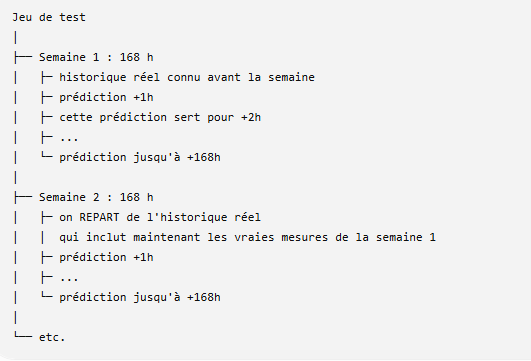

In [51]:
# Stockage de toutes les prédictions du test final.
all_test_predictions = []

# Le modèle étant global, on évalue tous les sites.
site_ids = catboost_data["site_id"].unique()

for site_id in site_ids:

    # Récupération de toute la période de test du site.
    site_test_data = (
        catboost_data[
            (catboost_data["site_id"] == site_id)
            & (catboost_data["timestamp"] > validation_end)
        ]
        .sort_values("timestamp")
        .copy()
    )

    # Découpage du test en fenêtres successives de 168 heures.
    for start in range(0, len(site_test_data), 168):

        test_window = site_test_data.iloc[start:start + 168].copy()

        # La dernière fenêtre est ignorée si elle ne contient pas
        # les 168 heures nécessaires.
        if len(test_window) < 168:
            continue

        window_start = test_window["timestamp"].iloc[0]

        # Historique réellement connu au début de cette fenêtre.
        # Pour les fenêtres suivantes, les consommations réellement observées
        # lors des semaines précédentes sont donc à nouveau disponibles.
        history = (
            catboost_data[
                (catboost_data["site_id"] == site_id)
                & (catboost_data["timestamp"] < window_start)
            ]
            .sort_values("timestamp")["consumption_kwh_corrected"]
            .tolist()
        )

        # Prévision récursive des 168 prochaines heures.
        for horizon, (_, row) in enumerate(test_window.iterrows(), start=1):

            X_row = pd.DataFrame([{
                "site_id": row["site_id"],
                "site_type": row["site_type"],
                "hour": row["hour"],
                "day_of_week": row["day_of_week"],
                "month": row["month"],
                "is_weekend": row["is_weekend"],
                "is_working_hours": row["is_working_hours"],

                "consumption_lag_1h": history[-1],
                "consumption_lag_2h": history[-2],
                "consumption_lag_24h": history[-24],
                "consumption_lag_48h": history[-48],
                "consumption_lag_168h": history[-168],

                "rolling_mean_24h": np.mean(history[-24:]),
                "rolling_mean_168h": np.mean(history[-168:]),
            }], columns=catboost_features)

            prediction = final_model.predict(X_row)[0]

            all_test_predictions.append({
                "site_id": site_id,
                "window_start": window_start,
                "timestamp": row["timestamp"],
                "horizon": horizon,
                "y": row["consumption_kwh"],
                "yhat": prediction,
            })

            # La prédiction devient une entrée de l'historique
            # pour calculer les lags des heures suivantes de la fenêtre.
            history.append(prediction)

# Regroupement de toutes les prédictions.
final_test_results = pd.DataFrame(all_test_predictions)

display(final_test_results.head())

print("Nombre total de prédictions :", len(final_test_results))
print("Nombre de sites testés :", final_test_results["site_id"].nunique())
print(
    "Nombre de fenêtres testées :",
    final_test_results[["site_id", "window_start"]].drop_duplicates().shape[0],
)

,site_id,window_start,timestamp,horizon,y,yhat
0,SITE001,2024-09-12 13:00:00,2024-09-12 13:00:00,1,183.21,202.281521
1,SITE001,2024-09-12 13:00:00,2024-09-12 14:00:00,2,202.90,202.816040
2,SITE001,2024-09-12 13:00:00,2024-09-12 15:00:00,3,197.31,203.676035
3,SITE001,2024-09-12 13:00:00,2024-09-12 16:00:00,4,217.21,209.899577
4,SITE001,2024-09-12 13:00:00,2024-09-12 17:00:00,5,222.44,210.522728


Nombre total de prédictions : 17640
Nombre de sites testés : 7
Nombre de fenêtres testées : 105


In [52]:
# On retire uniquement les lignes dont la consommation réelle est manquante.
final_test_eval = final_test_results.dropna(subset=["y"]).copy()

# Métriques globales sur l'ensemble des sites et des fenêtres.
final_test_mae = mean_absolute_error(
    final_test_eval["y"],
    final_test_eval["yhat"],
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        final_test_eval["y"],
        final_test_eval["yhat"],
    )
)

print("Nombre de prédictions évaluées :", len(final_test_eval))
print("MAE globale :", final_test_mae)
print("RMSE globale :", final_test_rmse)

Nombre de prédictions évaluées : 17231
MAE globale : 77.15899147329472
RMSE globale : 186.65533942293945


In [53]:
# Calcul des performances pour chaque site.
site_results = []

for site_id, group in final_test_eval.groupby("site_id"):

    site_mae = mean_absolute_error(
        group["y"],
        group["yhat"],
    )

    site_rmse = np.sqrt(
        mean_squared_error(
            group["y"],
            group["yhat"],
        )
    )

    site_results.append({
        "site_id": site_id,
        "MAE": site_mae,
        "RMSE": site_rmse,
        "predictions": len(group),
    })

site_results_df = pd.DataFrame(site_results)

display(site_results_df)

,site_id,MAE,RMSE,predictions
0,SITE001,25.147783,53.679503,2479
1,SITE002,126.269186,261.988192,2465
2,SITE003,106.800767,234.999788,2462
3,SITE004,47.321003,108.711386,2471
4,SITE005,91.143817,165.187050,2435
5,SITE006,16.807366,31.990270,2455
6,SITE007,126.972694,277.595697,2464


In [58]:
# Comparaison de l'erreur avec le niveau moyen de consommation de chaque site.
site_comparison = []

for site_id, group in final_test_eval.groupby("site_id"):

    mean_consumption = group["y"].mean()

    mae = mean_absolute_error(
        group["y"],
        group["yhat"],
    )

    rmse = np.sqrt(
        mean_squared_error(
            group["y"],
            group["yhat"],
        )
    )

    site_comparison.append({
        "site_id": site_id,
        "consumption_moyenne_kwh": mean_consumption,
        "MAE": mae,
        "MAE_%": (mae / mean_consumption) * 100,
        "RMSE": rmse,
        "RMSE_%": (rmse / mean_consumption) * 100,
    })

site_comparison_df = pd.DataFrame(site_comparison)

# Récupération du type associé à chaque site.
site_types = (
    catboost_data[
        ["site_id", "site_type"]
    ]
    .drop_duplicates()
)

# Ajout du type de site au tableau des résultats.
site_comparison_df = site_comparison_df.merge(
    site_types,
    on="site_id",
    how="left",
)

# Réorganisation des colonnes pour faciliter la lecture.
site_comparison_df = site_comparison_df[
    [
        "site_id",
        "site_type",
        "consumption_moyenne_kwh",
        "MAE",
        "MAE_%",
        "RMSE",
        "RMSE_%",
    ]
]

display(site_comparison_df)

,site_id,site_type,consumption_moyenne_kwh,MAE,MAE_%,RMSE,RMSE_%
0,SITE001,office,127.094764,25.147783,19.786640,53.679503,42.235810
1,SITE002,factory,695.759582,126.269186,18.148393,261.988192,37.654989
2,SITE003,datacenter,941.100065,106.800767,11.348503,234.999788,24.970755
3,SITE004,retail,291.576172,47.321003,16.229379,108.711386,37.284043
4,SITE005,hospital,607.946468,91.143817,14.992079,165.187050,27.171315
5,SITE006,office,121.353894,16.807366,13.849878,31.990270,26.361140
6,SITE007,factory,696.582642,126.972694,18.227944,277.595697,39.851079


### Analyse des performances par site

Les sites présentent des niveaux de consommation très différents. Une comparaison basée uniquement sur la MAE en kWh peut donc être trompeuse : une erreur de 100 kWh est beaucoup plus importante pour un petit site que pour un site consommant près de 1 000 kWh par heure.

La MAE est donc également rapportée à la consommation moyenne de chaque site.

Les erreurs relatives observées sont comprises entre environ **11 % et 20 %** selon les sites. Le modèle obtient notamment sa meilleure erreur relative sur le `datacenter` (`SITE003`) avec environ **11,35 %**, malgré une MAE absolue supérieure à 100 kWh.

Les deux sites de type `factory` présentent des résultats très proches, autour de **18 % d'erreur moyenne**, tandis que les deux sites de type `office` présentent respectivement environ **19,8 %** et **13,8 %**.

Ces résultats montrent que les différences importantes de MAE absolue entre les sites proviennent en partie de leurs niveaux de consommation très différents.

### Validation finale du modèle

Le modèle a été évalué sur l'ensemble des sites et sur plusieurs fenêtres de prévision allant jusqu'à 168 heures.

Afin de tenir compte des différences importantes de consommation entre les sites, la MAE a été rapportée à la consommation moyenne de chaque site. Les erreurs relatives obtenues sont comprises entre environ **11 % et 20 %**.

Le critère d'acceptation retenu pour le MVP étant une erreur moyenne relative inférieure à **20 %**, les résultats obtenus permettent de valider le modèle sur le jeu de test.

La configuration finale retenue est donc **CatBoost**, avec les features et hyperparamètres sélectionnés lors de la phase de validation.